In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv("series_simulees_acf.csv")

print(df.head())
print(df.columns)

   t  bruit_blanc  persistante  saisonniere  tendance
0  1     0.496714     0.000000     0.495127  0.301840
1  2    -0.138264     0.357787    -0.137771  0.635591
2  3     0.647689     0.847014     0.626275 -0.677732
3  4     1.523030     1.760663     1.002097  0.785685
4  5    -0.234153     2.462332     0.884818  1.204510
Index(['t', 'bruit_blanc', 'persistante', 'saisonniere', 'tendance'], dtype='str')


In [27]:
def acf(series, nlags):
    acfs = []

    for lag in range(nlags):
        if lag == 0:
            acfs.append(1)
            continue

        corr = np.corrcoef(series[lag:], series[:-lag])[0, 1]
        acfs.append(corr)

    return acfs

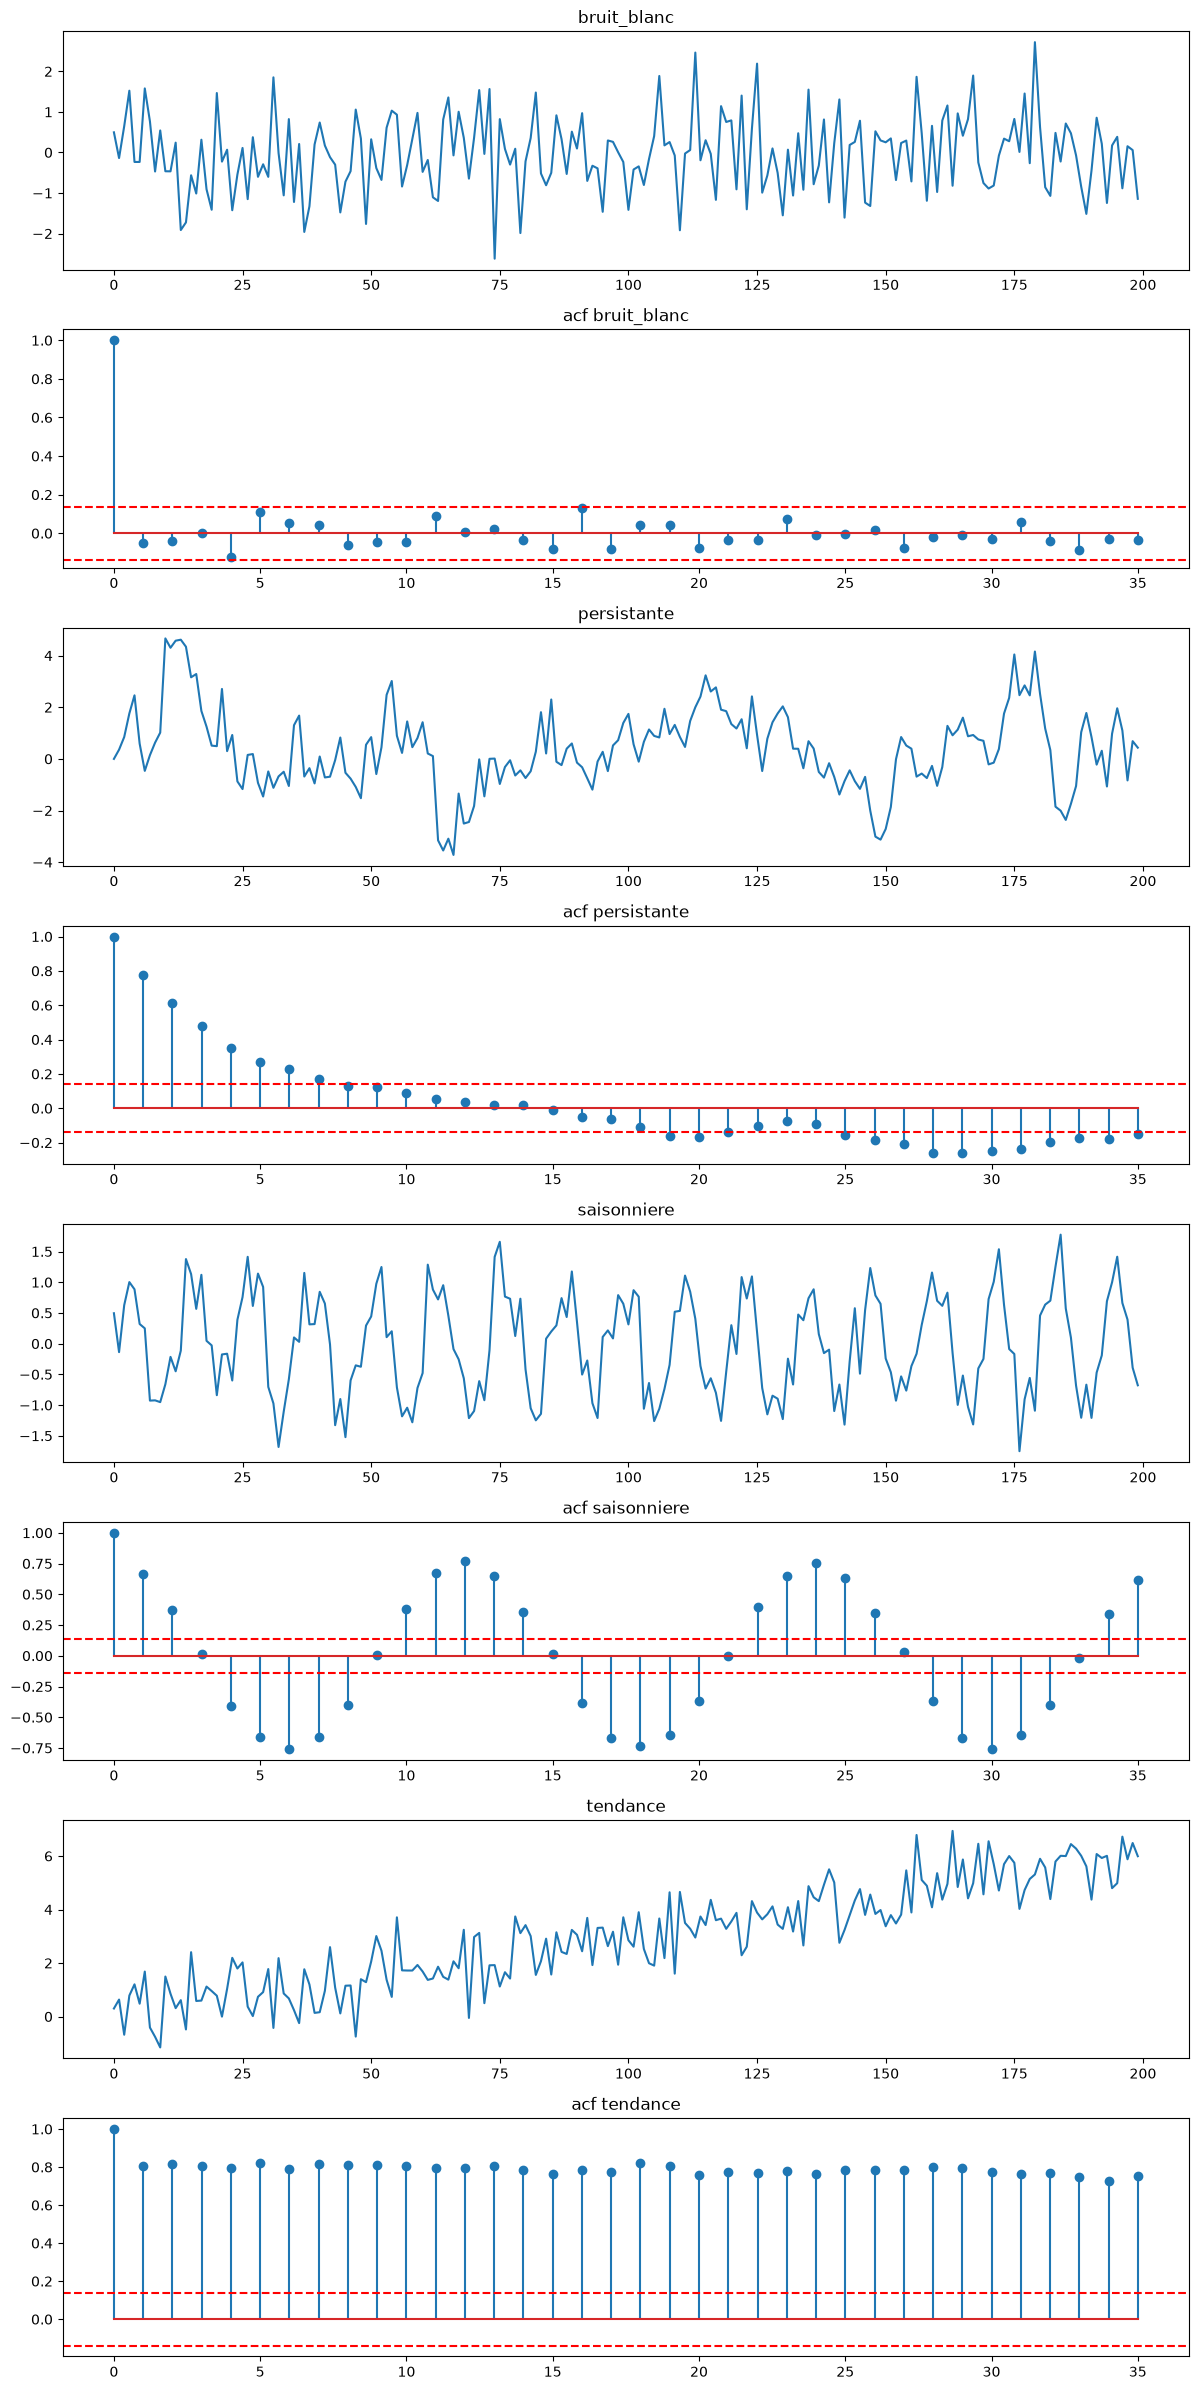

In [36]:
fig, axes = plt.subplots(8, 1, figsize=(12, 24)) 

i = 0
for col in df.columns:
    if col == "t": continue

    significance = 1.96 / np.sqrt(len(df[col]))

    axes[i].plot(df[col])
    axes[i].set_title(col)

    axes[i + 1].stem(range(36), acf(df[col], 36))
    axes[i + 1].set_title(f"acf {col}")
    axes[i + 1].axhline(significance, color="red", linestyle="--")
    axes[i + 1].axhline(-significance, color="red", linestyle="--")

    i += 2

plt.tight_layout()
plt.show()

- Bruit : La série fluctue autour d’une moyenne sans tendance ni saisonnalité. ACF est insignifiant. Cela signifie que le bruit est indépendant et n'a pas de autocorrelation.
- Persistante :
- Saisonniere : La série présente des fluctuations périodiques. l'ACF oscillet autour de zéro, les pics de l'ACF correspondent à la période saisonnière.
- Tendance : La série a une tendance croissante, donc il y a un fort autocorrelation et l'ACF est large et décroit lentement.

# Simulation

In [83]:
phis = [0.2, 0.5, -0.7, 0.8, 0.8, 0.8, 0.8]
xs = []
steps = 300

for i in range(len(phis)):
    phi = phis[i]
    x = [0]
    for t in range(1, steps + 50):
        x.append(phi * x[t - 1] + np.random.normal(0, 1))
    xs.append(x[50:])

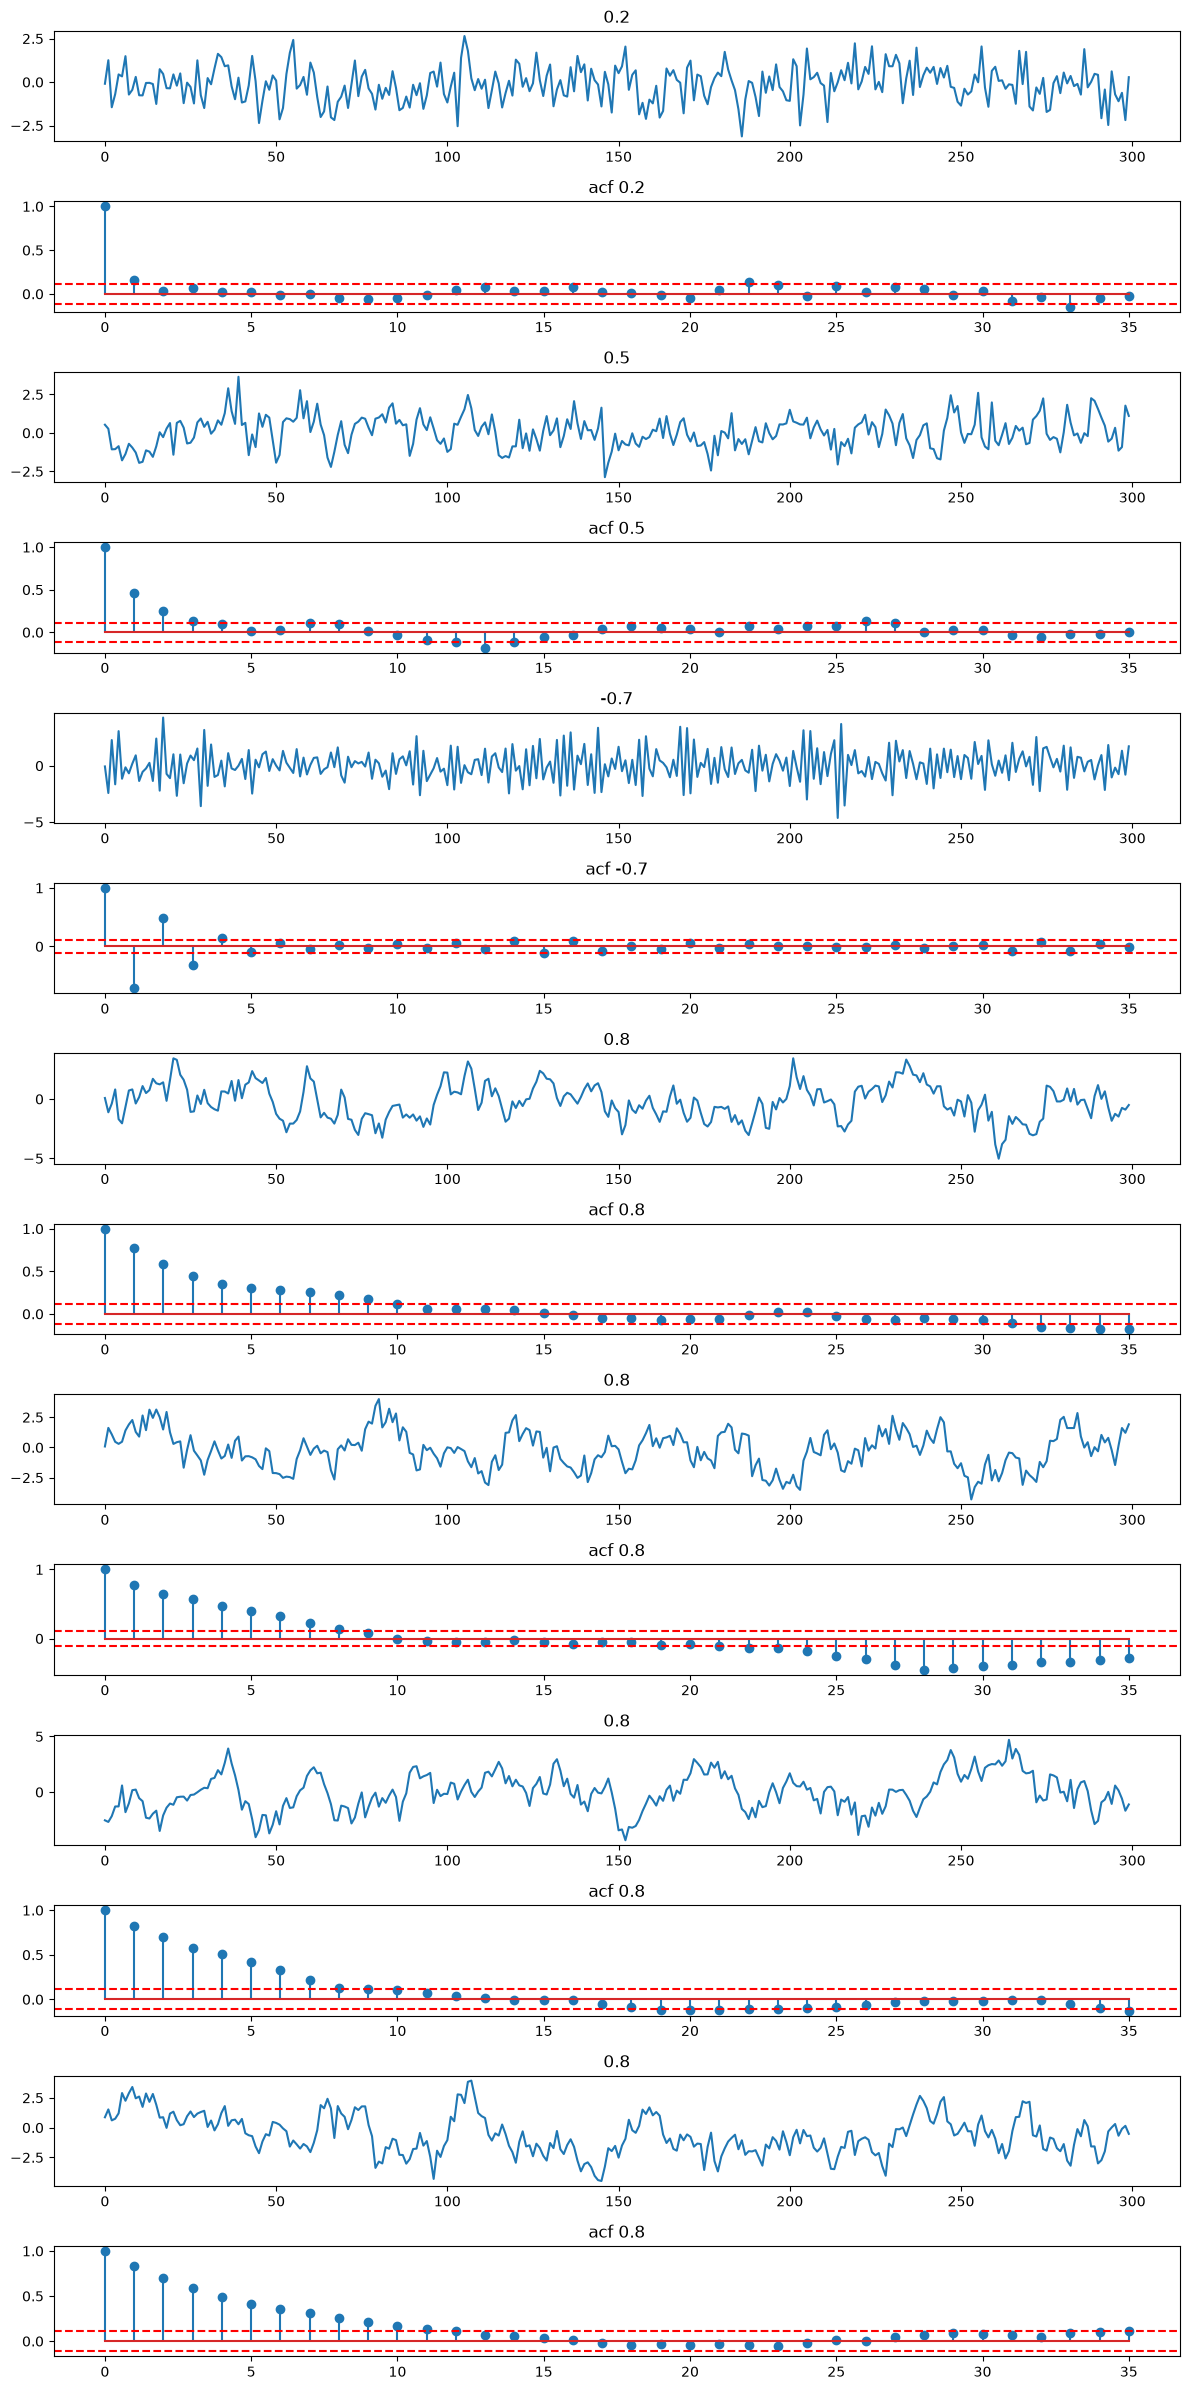

In [84]:
fig, axes = plt.subplots(len(phis) * 2, 1, figsize=(12, 24)) 

i = 0
for x in xs:
    significance = 1.96 / np.sqrt(len(x))

    axes[i].plot(x)
    axes[i].set_title(phis[i // 2])

    axes[i + 1].stem(range(36), acf(x, 36))
    axes[i + 1].set_title(f"acf {phis[i // 2]}")
    axes[i + 1].axhline(significance, color="red", linestyle="--")
    axes[i + 1].axhline(-significance, color="red", linestyle="--")

    i += 2

plt.tight_layout()
plt.show()

# Simulation Bruit

In [85]:
x = [0]
for t in range(1, steps + 50):
    x.append(0.03 * t + np.random.normal(0, 1))

x = x[50:]

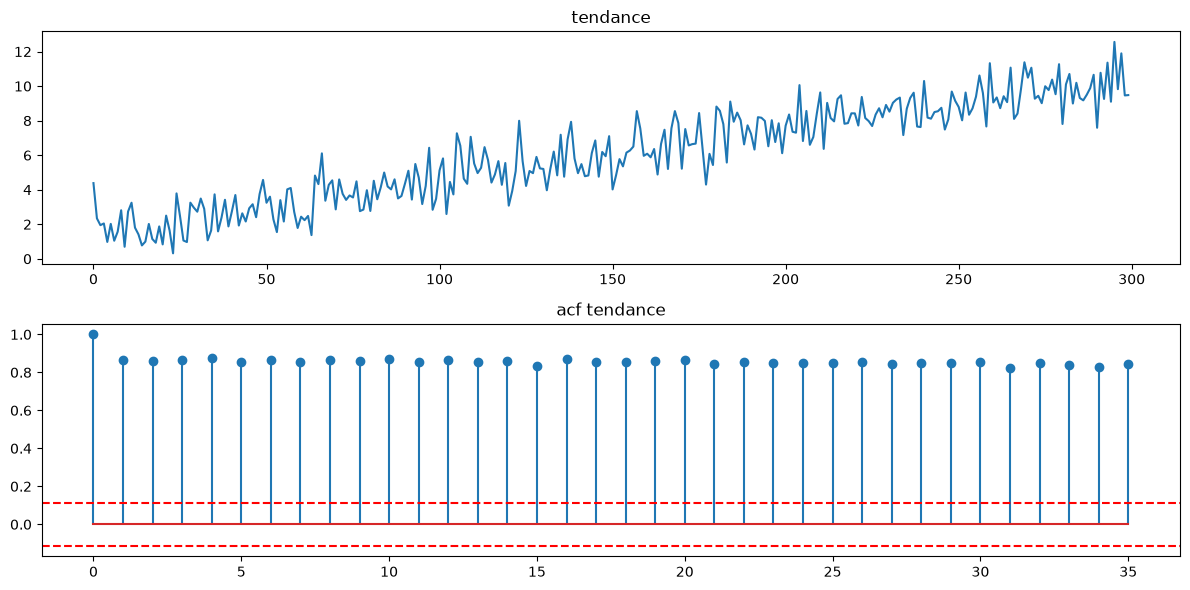

In [86]:
fig, axes = plt.subplots(2, figsize=(12, 6)) 

significance = 1.96 / np.sqrt(len(x))

axes[0].plot(x)
axes[0].set_title("tendance")

axes[1].stem(range(36), acf(x, 36))
axes[1].set_title(f"acf tendance")
axes[1].axhline(significance, color="red", linestyle="--")
axes[1].axhline(-significance, color="red", linestyle="--")

plt.tight_layout()
plt.show()

In [87]:
lg = LinearRegression()
lg.fit(np.arange(steps).reshape(-1, 1), x)

print(lg.coef_)

[0.03008263]


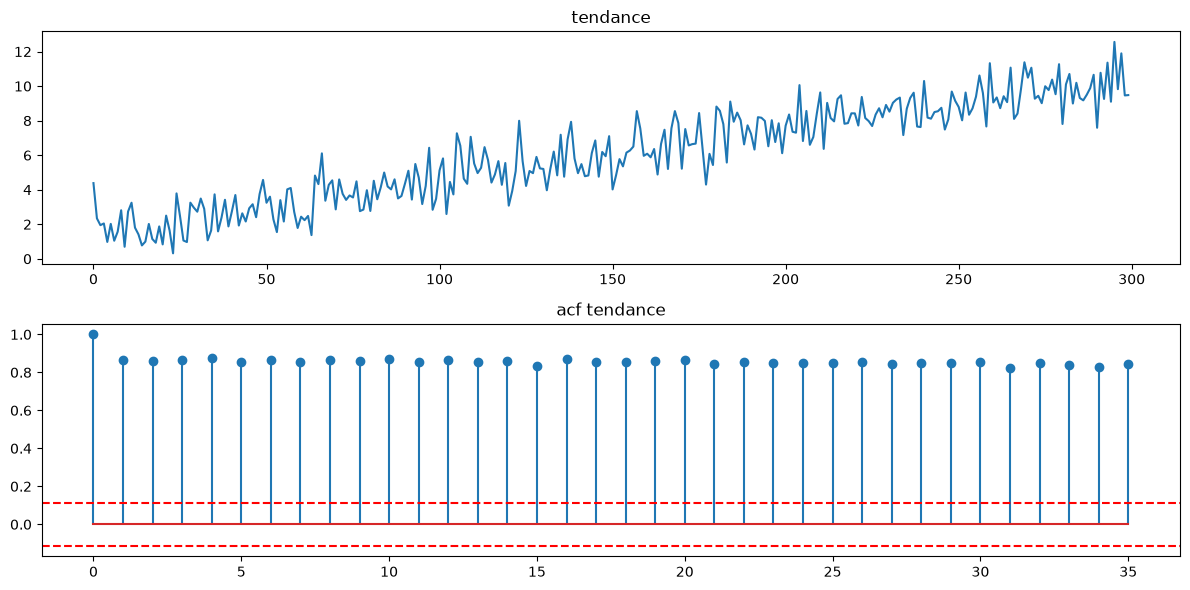

In [88]:
fig, axes = plt.subplots(2, figsize=(12, 6)) 

significance = 1.96 / np.sqrt(len(x))

axes[0].plot(x)
axes[0].set_title("tendance")

axes[1].stem(range(36), acf(x, 36))
axes[1].set_title(f"acf tendance")
axes[1].axhline(significance, color="red", linestyle="--")
axes[1].axhline(-significance, color="red", linestyle="--")

plt.tight_layout()
plt.show()